# Import data from kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("padmapriyatr/netflix-titles")

print("Path to dataset files:", path)

c:\Users\adity\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.34M/1.34M [00:01<00:00, 995kB/s]

Extracting files...
Path to dataset files: C:\Users\adity\.cache\kagglehub\datasets\padmapriyatr\netflix-titles\versions\1


# Knowledge about data

In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\adity\.cache\kagglehub\datasets\padmapriyatr\netflix-titles\versions\1\netflix_titles.csv")
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

# Visualize DATA
# Bar Chart  
* Number of TV show VS Movie

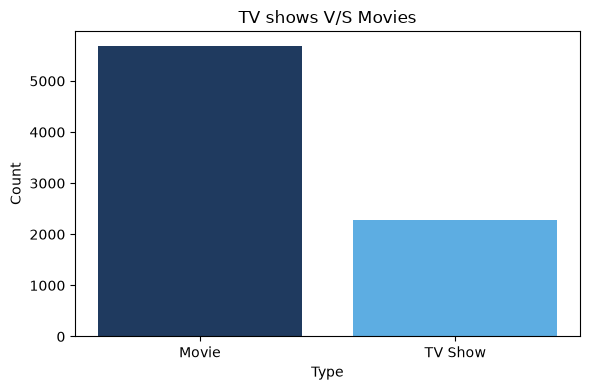

In [10]:
import matplotlib.pyplot as plt

df = df.dropna(subset=["type", "release_year", "rating", "country", "duration"])

type_count = df["type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(type_count.index, type_count.values, color = ["#1F3A5F", "#5DADE2"])
plt.title("TV shows V/S Movies")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("tvshows_vs_movies.png", dpi=300)
plt.show()

# Pie chart
* Percentage of Content Rating

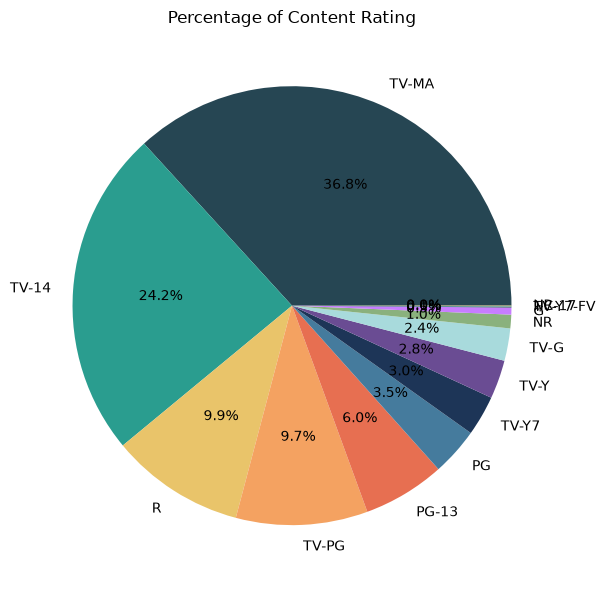

In [11]:
rating_count = df["rating"].value_counts()

plt.figure(figsize=(8,6))
colors = [
    "#264653",  # Dark Teal
    "#2A9D8F",  # Teal
    "#E9C46A",  # Gold
    "#F4A261",  # Orange
    "#E76F51",  # Coral
    "#457B9D",  # Blue
    "#1D3557",  # Navy
    "#6A4C93",  # Purple
    "#A8DADC",  # Light Cyan
    "#8AB17D",  # Green
    "#C77DFF"   # Violet
]
plt.pie(rating_count, labels=rating_count.index, autopct="%1.1f%%", colors=colors)
plt.title("Percentage of Content Rating")
plt.tight_layout()
plt.savefig("Content_rating_pie.png", dpi=300)
plt.show()

# Histogram
* Distribution of Movie Duration

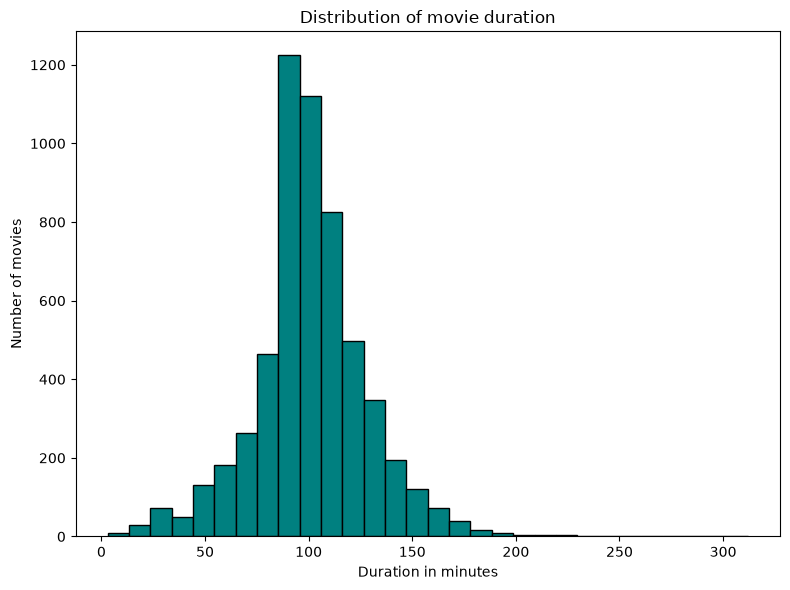

In [20]:
movie_df = df[df["type"] == "Movie"].copy()

movie_df["duration_int"] = movie_df["duration"].str.replace('min', '').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df["duration_int"], bins = 30, color="Teal", edgecolor="black")
plt.title("Distribution of movie duration")
plt.xlabel("Duration in minutes")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.savefig("movie_duration_histogram.png", dpi=300)
plt.show()

# Scatter Plot
* Release Year VS Number of Shows

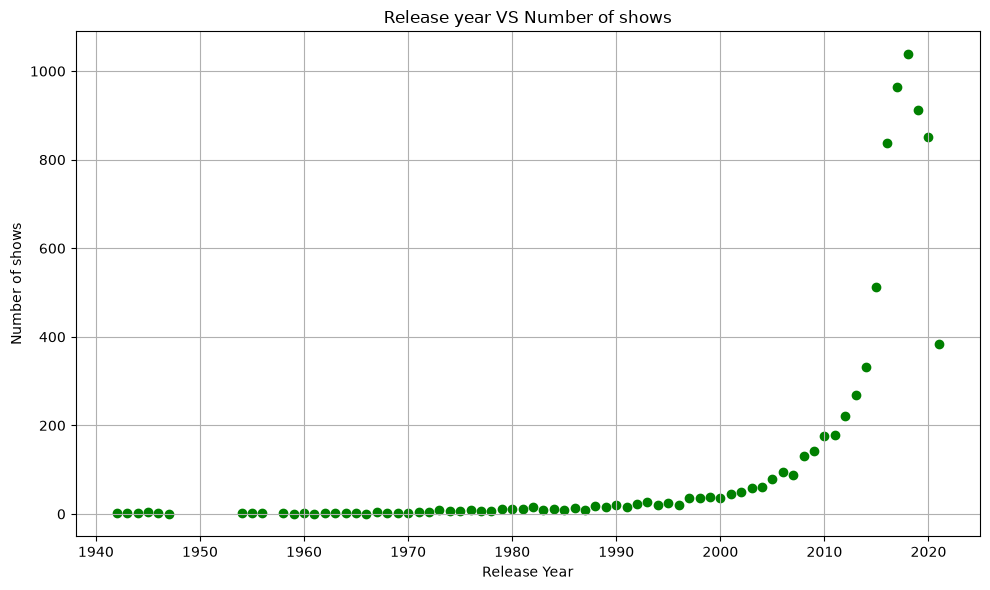

In [22]:
release_counts = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color="green")
plt.title("Release year VS Number of shows")
plt.xlabel("Release Year")
plt.ylabel("Number of shows")
plt.grid()
plt.tight_layout()
plt.savefig("release_vs_noshows_scatter.png", dpi=300)
plt.show()

# Barh plot
* Top 10 Countries by Number of Shows

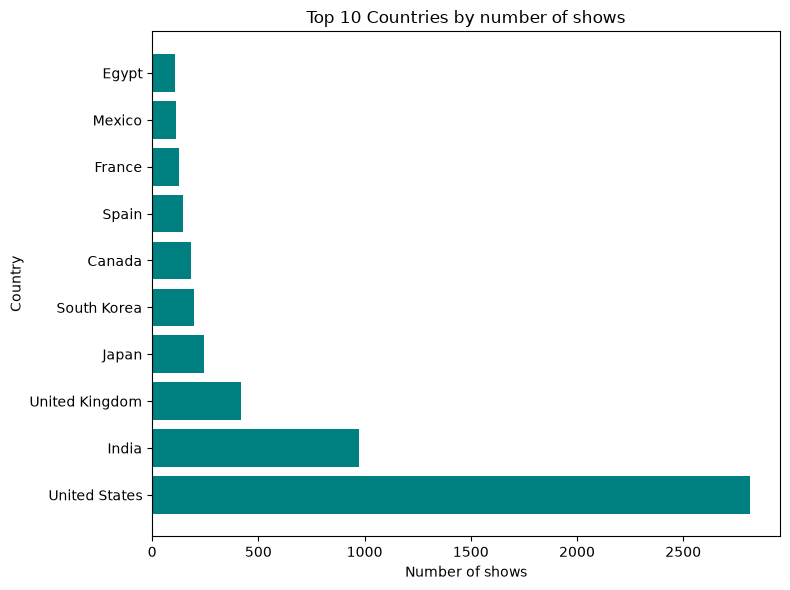

In [23]:
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color="teal")
plt.title("Top 10 Countries by number of shows")
plt.xlabel("Number of shows")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("Top10_country.png", dpi=300)
plt.show()

# Subplot
* Comparasion of Movies and TV Shows Released Over Years

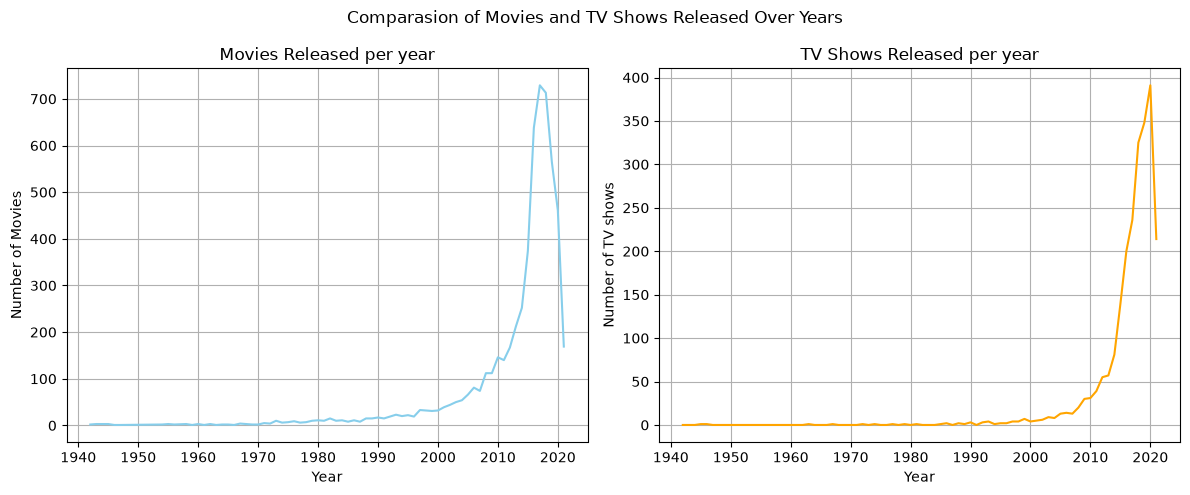

In [28]:
content_by_year = df.groupby(["release_year", "type"]).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12, 5))

# First subplot : Movies

ax[0].plot(content_by_year.index, content_by_year["Movie"], color='skyblue')
ax[0].set_title("Movies Released per year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")
ax[0].grid()

# Second subplot : TV Shows

ax[1].plot(content_by_year.index, content_by_year["TV Show"], color='orange')
ax[1].set_title("TV Shows Released per year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number of TV shows")
ax[1].grid()

fig.suptitle("Comparasion of Movies and TV Shows Released Over Years")

plt.tight_layout()
plt.savefig("movies_tvshows_comparasion.png",dpi=300)
plt.show()